# LGBM & XGBM

Objective:
The objective of this assignment is to compare the performance of Light GBM and XG Boost algorithms using the Titanic dataset. 

Note: The file given in assignment is Diabetes file. and asking the tasks about Titanic file. So, i am continue with diabetes file.
      

Exploratory Data Analysis (EDA):

In [81]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from sklearn.ensemble import AdaBoostClassifier,GradientBoostingClassifier
from sklearn.model_selection import train_test_split,GridSearchCV
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier

In [15]:
# 1.	Load the Titanic dataset using Python's pandas library.
df=pd.read_csv("Diabetes13.csv")

In [16]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [17]:
df.shape

(768, 9)

In [18]:
# 2.	Check for missing values.
df.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [19]:
## there is no missing data
## if we have any missing data, we need to do fillna or dropna based on requirement
df.dropna(inplace=True)
df.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [20]:
## checking for duplicates
df.duplicated().sum()

np.int64(0)

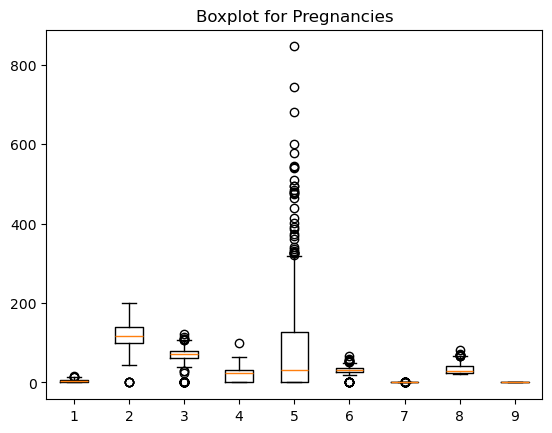

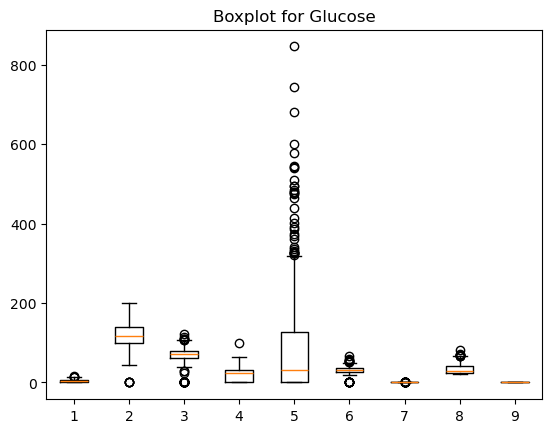

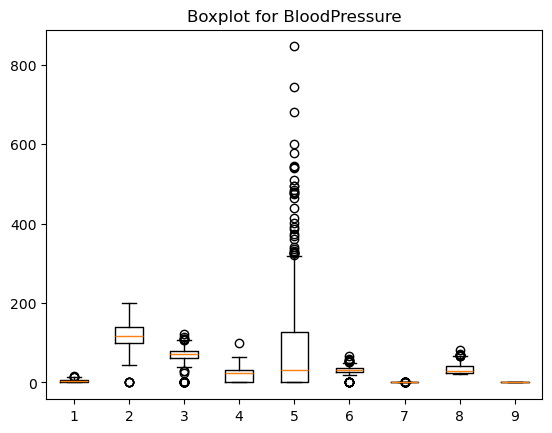

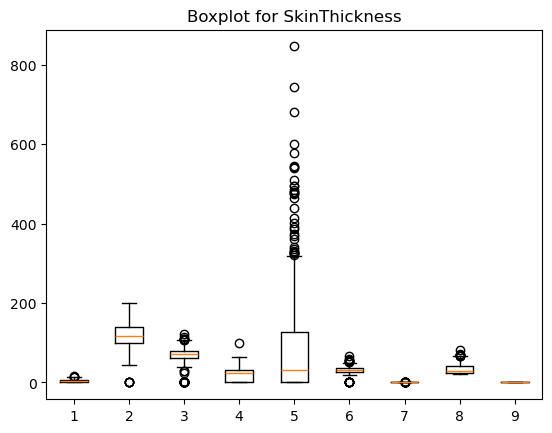

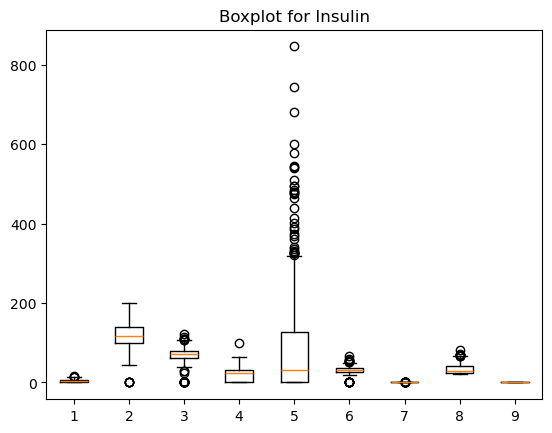

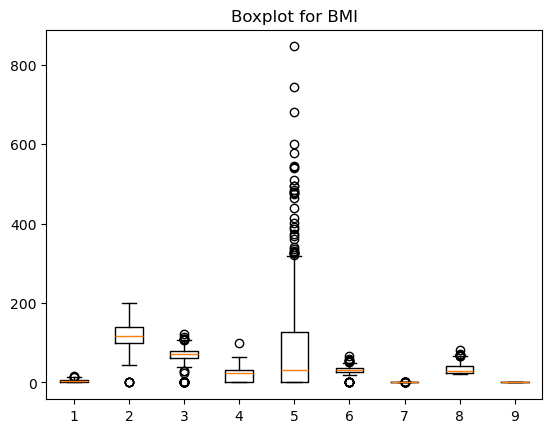

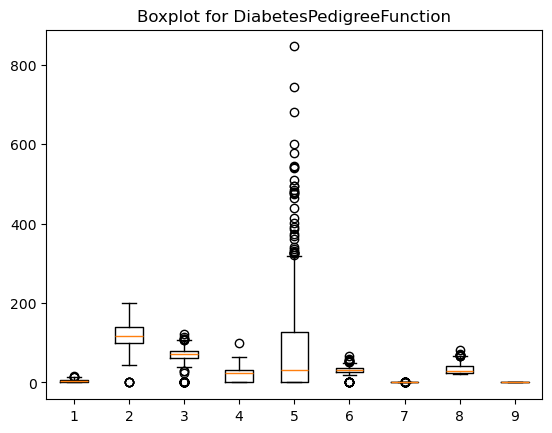

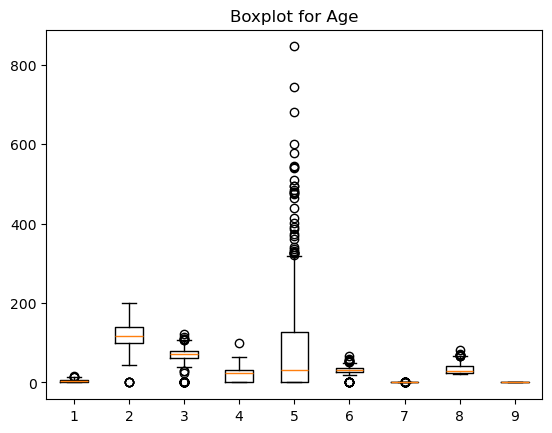

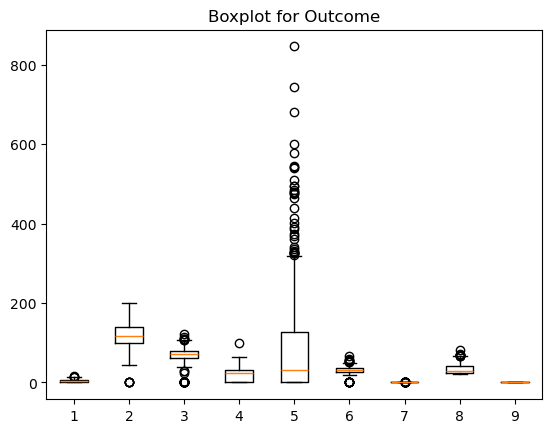

In [21]:
### checking for outliers
for col in df:
    plt.boxplot(df)
    plt.title(f"Boxplot for {col}")
    plt.show()

In [22]:
## capping outliers to upper and lower extreme values
def outlier_capping(df,columns):
    Q1= df[columns].quantile(0.25)
    Q3= df[columns].quantile(0.75)
    IQR= Q3-Q1
    lower_extreme= Q1-1.5*IQR
    upper_extreme= Q3+1.5*IQR
    df[columns]= df[columns].apply(lambda x: lower_extreme if x<lower_extreme else upper_extreme if x>upper_extreme else x)
for col in df:
    outlier_capping(df,col)

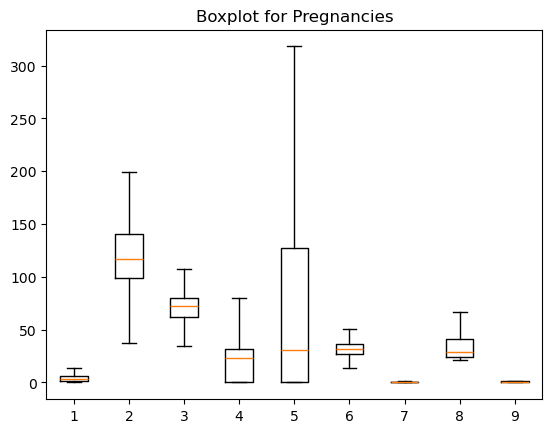

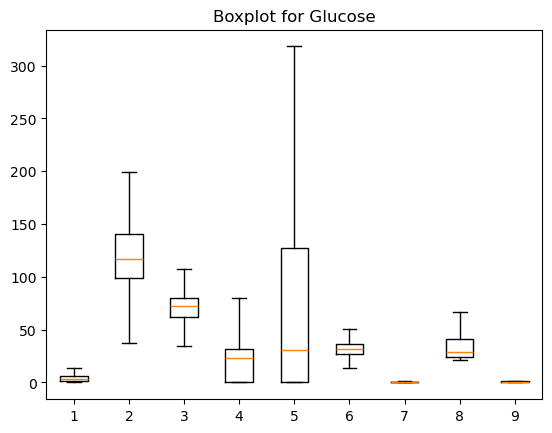

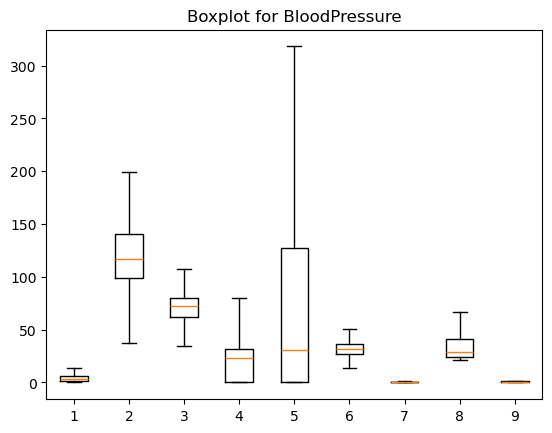

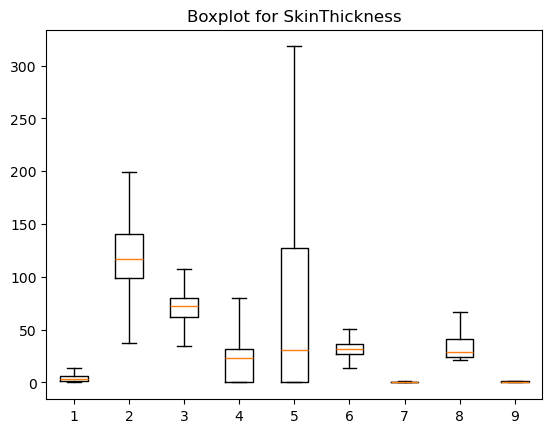

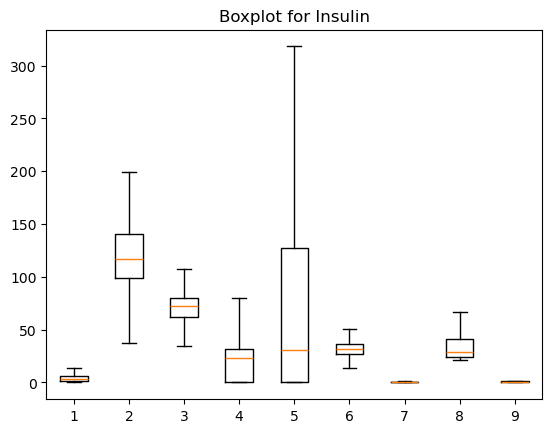

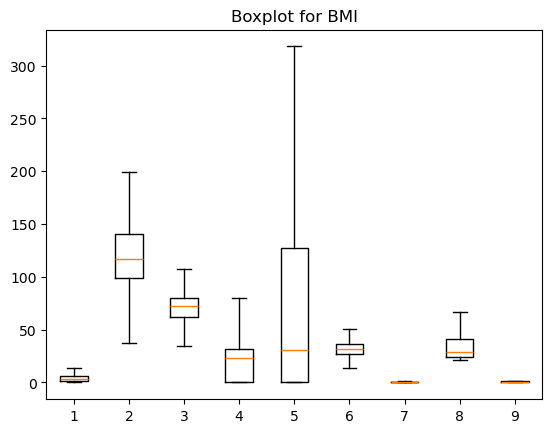

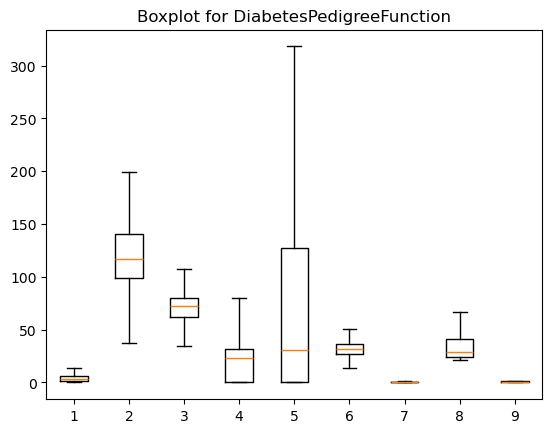

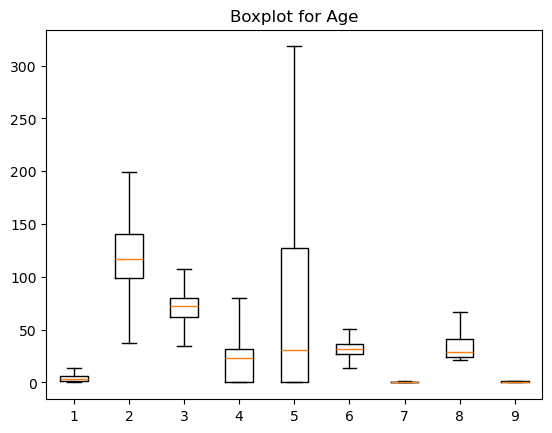

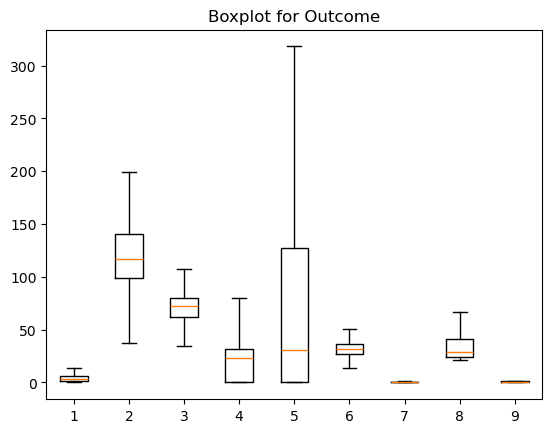

In [23]:
##3 outliers checking after capping
for col in df:
    plt.boxplot(df)
    plt.title(f"Boxplot for {col}")
    plt.show()

In [24]:
### there are no outliers

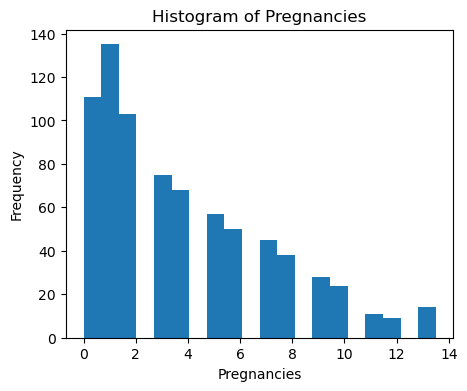

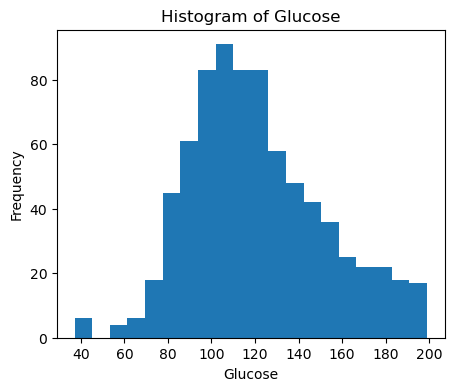

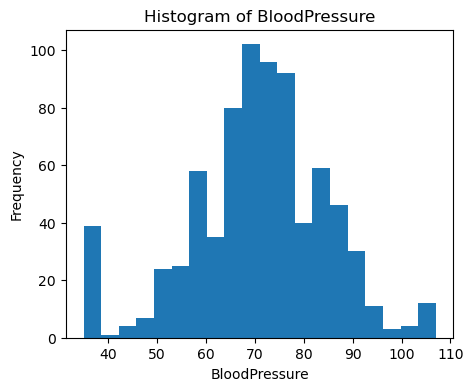

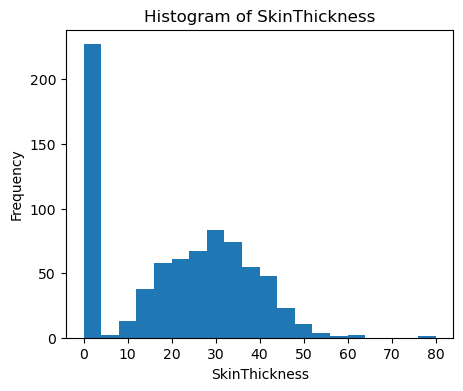

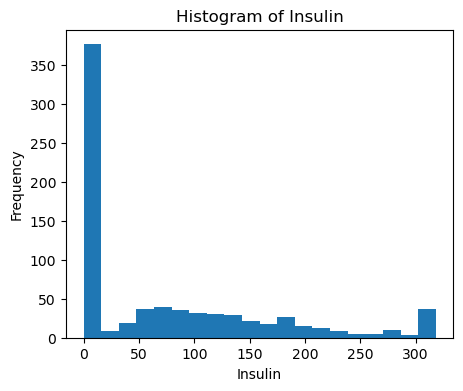

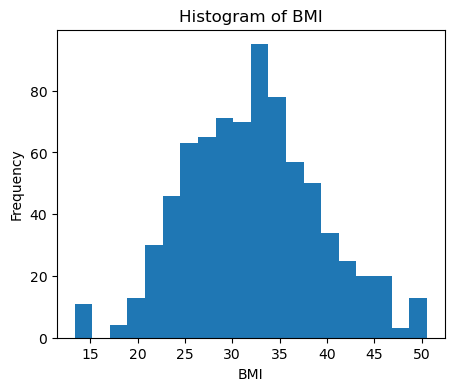

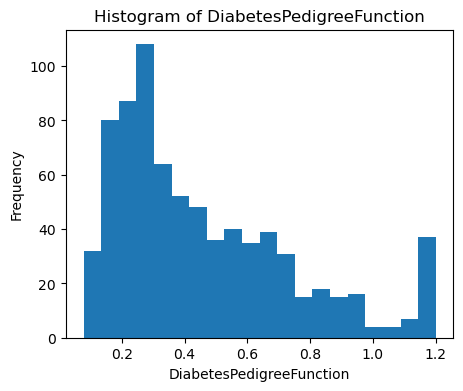

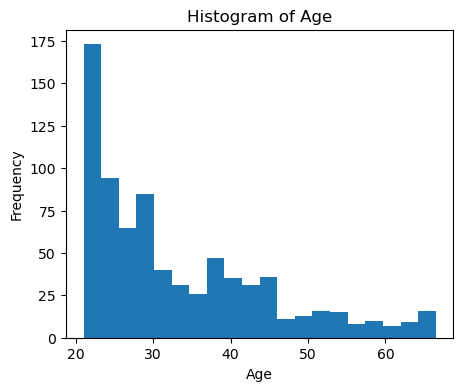

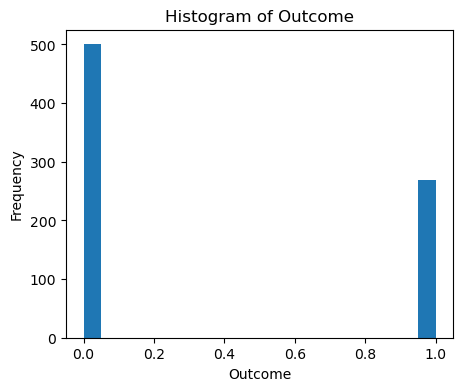

In [25]:

# 3.	Explore data distributions using histograms and box plots.
## histogram plotting
for col in df:
    plt.figure(figsize=(5,4))
    plt.hist(df[col].dropna(), bins=20)
    plt.title(f"Histogram of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()

In [26]:
### by seeing the histogram, data is not normally distributed

In [27]:
### finding skewness
for col in df:
    skewness = df[col].skew()
    print(f"Skewness for {col}:" , skewness)

Skewness for Pregnancies: 0.8539617478323778
Skewness for Glucose: 0.4179462206775283
Skewness for BloodPressure: -0.4060355281846069
Skewness for SkinThickness: 0.02666298054109206
Skewness for Insulin: 1.1738981213083215
Skewness for BMI: 0.13580859812143145
Skewness for DiabetesPedigreeFunction: 1.0244278033317116
Skewness for Age: 1.0671703233262797
Skewness for Outcome: 0.635016643444986


In [28]:
### based on skewness data is not normally distributed. It have moderate to high positive and negative skewness.

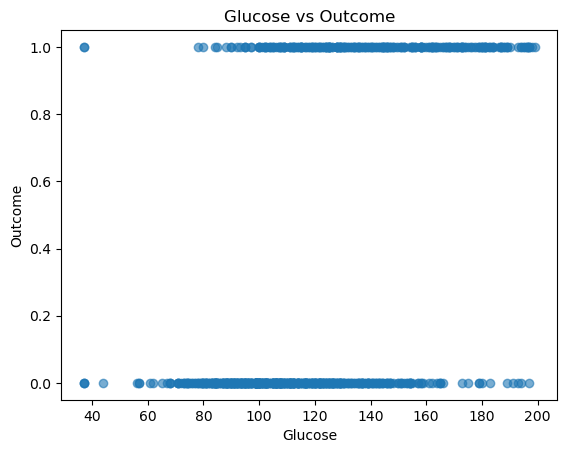

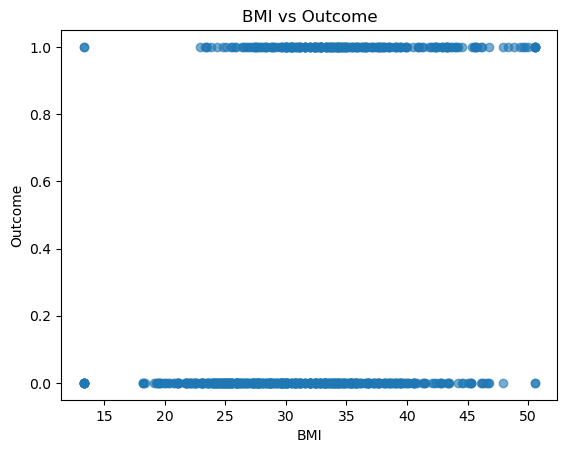

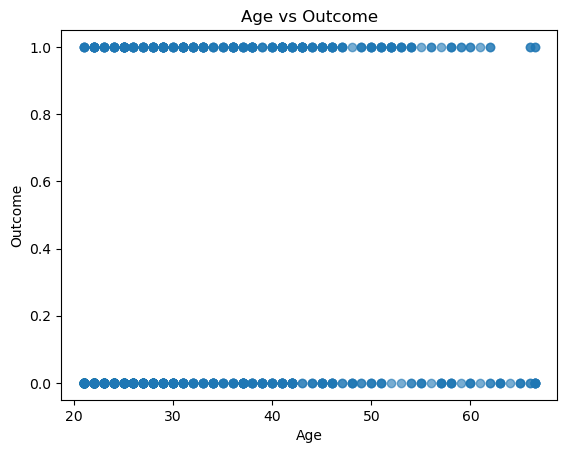

In [29]:
#4.	Visualize relationshipsts. between features and survival using scatter plots and bar plot
###  Scatter plot

## Scatter Plot – Glucose vs Outcome

plt.figure()
plt.scatter(df['Glucose'], df['Outcome'], alpha=0.6)
plt.xlabel('Glucose')
plt.ylabel('Outcome')
plt.title('Glucose vs Outcome')
plt.show()

# Scatter Plot – BMI vs Outcome

plt.figure()
plt.scatter(df['BMI'], df['Outcome'], alpha=0.6)
plt.xlabel('BMI')
plt.ylabel('Outcome')
plt.title('BMI vs Outcome')
plt.show()

# Scatter Plot – Age vs Outcome

plt.figure()
plt.scatter(df['Age'], df['Outcome'], alpha=0.6)
plt.xlabel('Age')
plt.ylabel('Outcome')
plt.title('Age vs Outcome')
plt.show()

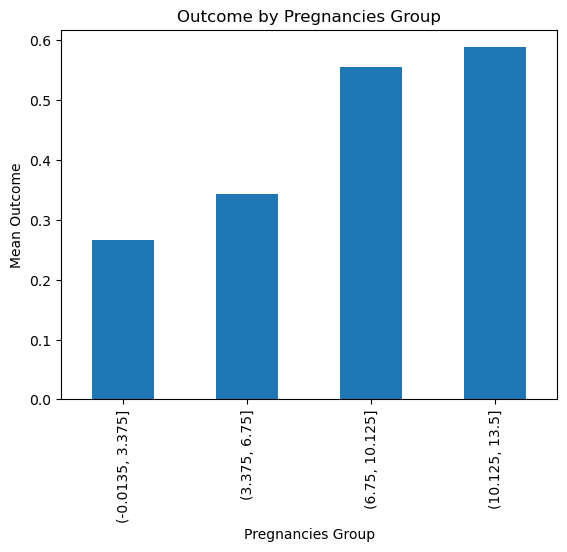

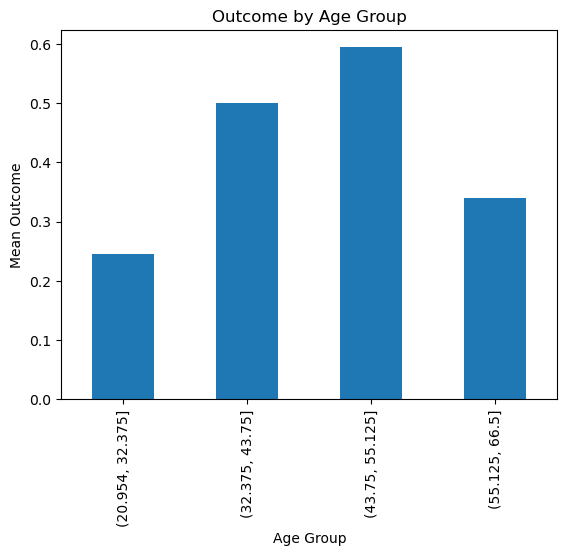

In [30]:
## Barplot

#Bar Plot – Outcome by Pregnancies (Binned)

#Bar plots work better for categorical data, so we bin numeric values.

df['Preg_bin'] = pd.cut(df['Pregnancies'], bins=4)

preg_group = df.groupby('Preg_bin')['Outcome'].mean()

plt.figure()
preg_group.plot(kind='bar')
plt.xlabel('Pregnancies Group')
plt.ylabel('Mean Outcome')
plt.title('Outcome by Pregnancies Group')
plt.show()

# Bar Plot – Outcome by Age Group
df['Age_bin'] = pd.cut(df['Age'], bins=4)

age_group = df.groupby('Age_bin')['Outcome'].mean()

plt.figure()
age_group.plot(kind='bar')
plt.xlabel('Age Group')
plt.ylabel('Mean Outcome')
plt.title('Outcome by Age Group')
plt.show()

Data Preprocessing:

In [31]:
# 1.Impute missing values.
##  It has been taken care of


In [32]:
# 2.Encode categorical variables using one-hot encoding or label encoding. 

# Identify Categorical Columns
cat_cols = df.select_dtypes(include=['object'])


In [33]:
### there is no categorial data in the file.

In [34]:
# 3.	If needed you can apply more preprocessing methods on the given dataset.

# Feature Scaling (Standardization)
from sklearn.preprocessing import StandardScaler

df = df.drop(columns=['Age_bin', 'Preg_bin'], errors='ignore')

features = df.drop('Outcome', axis=1)
target = df['Outcome']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(features)

In [35]:
features.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
0,6.0,148.0,72.0,35.0,0.0,33.6,0.627,50.0
1,1.0,85.0,66.0,29.0,0.0,26.6,0.351,31.0
2,8.0,183.0,64.0,0.0,0.0,23.3,0.672,32.0
3,1.0,89.0,66.0,23.0,94.0,28.1,0.167,21.0
4,0.0,137.0,40.0,35.0,168.0,43.1,1.200,33.0


In [36]:
target.head()

0    1
1    0
2    1
3    0
4    1
Name: Outcome, dtype: int64

Building Predictive Models:

1.	Split the preprocessed dataset into training and testing sets.
  
2.	Choose appropriate evaluation metrics (e.g., accuracy, precision, recall, F1-score) for model evaluation.
  
3.	Build predictive models using LightGBM and XGBoost algorithms.
  
4.	Train the models on the training set and evaluate their performance on the testing set.
  
5.	Use techniques like cross-validation and hyperparameter tuning to optimize model performance.


In [37]:
# 1.	Split the preprocessed dataset into training and testing sets.

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(features, target, test_size=0.2, random_state=42, stratify=target)
    
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(614, 8)
(154, 8)
(614,)
(154,)


In [38]:
X_train.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
353,1.0,90.0,62.0,12.0,43.0,27.2,0.580,24.0
711,5.0,126.0,78.0,27.0,22.0,29.6,0.439,40.0
373,2.0,105.0,58.0,40.0,94.0,34.9,0.225,25.0
46,1.0,146.0,56.0,0.0,0.0,29.7,0.564,29.0
682,0.0,95.0,64.0,39.0,105.0,44.6,0.366,22.0


In [39]:
X_test.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
44,7.0,159.0,64.0,0.0,0.0,27.40,0.294,40.0
672,10.0,68.0,106.0,23.0,49.0,35.50,0.285,47.0
700,2.0,122.0,76.0,27.0,200.0,35.90,0.483,26.0
630,7.0,114.0,64.0,0.0,0.0,27.40,0.732,34.0
81,2.0,74.0,35.0,0.0,0.0,13.35,0.102,22.0


XGBM-XGBOOST

In [37]:
pip install xgboost

   ---------------------------------------- 0.0/72.0 MB ? eta -:--:--
   ---- ----------------------------------- 7.6/72.0 MB 39.4 MB/s eta 0:00:02
   --------- ------------------------------ 17.8/72.0 MB 43.9 MB/s eta 0:00:02
   ------------ --------------------------- 22.3/72.0 MB 36.6 MB/s eta 0:00:02
   ---------------- ----------------------- 29.1/72.0 MB 34.4 MB/s eta 0:00:02
   -------------------- ------------------- 37.5/72.0 MB 36.0 MB/s eta 0:00:01
   -------------------------- ------------- 46.9/72.0 MB 37.3 MB/s eta 0:00:01
   ------------------------------- -------- 56.6/72.0 MB 38.7 MB/s eta 0:00:01
   ------------------------------------- -- 67.4/72.0 MB 40.2 MB/s eta 0:00:01
   ---------------------------------------  71.8/72.0 MB 40.8 MB/s eta 0:00:01
   ---------------------------------------- 72.0/72.0 MB 36.4 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


In [65]:
import xgboost as xgb
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix

In [66]:
xg_boost= xgb.XGBClassifier(n_estimators=100,learning_rate=0.1,min_child_weight=1,
                            subsample=0.9,max_features=1,reg_alpha=10,reg_lambda=10)

In [87]:
xg_boost.fit(X_train,y_train)
y_pred_xgboost= xg_boost.predict(X_test)
accuracy_score(y_test,y_pred_xgboost)

0.7467532467532467

In [88]:
### Gridsearch
params={'n_estimators':[50,100],'learning_rate':[0.1,0.5],'min_child_weight':[1,2,3]}

In [89]:
grid_search_xgboost= GridSearchCV(estimator=xg_boost,param_grid=params, cv=5)
grid_search_xgboost.fit(X_train,y_train)
grid_search_xgboost.best_params_, grid_search_xgboost.best_score_

({'learning_rate': 0.1, 'min_child_weight': 1, 'n_estimators': 100},
 np.float64(0.7704118352658936))

In [90]:
# evaluate the performance of XGboost
accuracy_xgboost = accuracy_score(y_test, y_pred_xgboost)
precision_xgboost = precision_score(y_test, y_pred_xgboost, average='weighted')  # Use 'weighted' for multi-class
recall_xgboost = recall_score(y_test, y_pred_xgboost, average='weighted')
f1_xgboost = f1_score(y_test, y_pred_xgboost, average='weighted')

print("XGboost Model Performance on Test Data:")
print(f"Accuracy xgboost: {accuracy_xgboost:.4f}")
print(f"Precision xgboost: {precision_xgboost:.4f}")
print(f"Recall xgboost  : {recall_xgboost:.4f}")
print(f"F1-score xgboost: {f1_xgboost:.4f}")

# Detailed classification report
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

XGboost Model Performance on Test Data:
Accuracy xgboost: 0.7468
Precision xgboost: 0.7401
Recall xgboost  : 0.7468
F1-score xgboost: 0.7407

Classification Report:

              precision    recall  f1-score   support

           0       0.79      0.82      0.80       100
           1       0.64      0.59      0.62        54

    accuracy                           0.74       154
   macro avg       0.71      0.71      0.71       154
weighted avg       0.74      0.74      0.74       154



LGBM

In [91]:
pip install lightgbm

Note: you may need to restart the kernel to use updated packages.


In [92]:
import lightgbm as lgbm

In [73]:
lgb= lgbm.LGBMClassifier(n_estimators=100,learning_rate=0.1,min_child_weight=1,
                            subsample=0.9,max_features=1,reg_alpha=10,reg_lambda=10,
                             max_bins=10,bundled=True,boosting_type='goss',top_rate=0.2,other_rate=0.3)

In [93]:
lgb.fit(X_train,y_train)
y_pred_lgb= lgb.predict(X_test)
accuracy_score(y_test,y_pred_lgb)

[LightGBM] [Warning] Unknown parameter: max_features
[LightGBM] [Warning] Unknown parameter: bundled
[LightGBM] [Warning] Found boosting=goss. For backwards compatibility reasons, LightGBM interprets this as boosting=gbdt, data_sample_strategy=goss.To suppress this warning, set data_sample_strategy=goss instead.
[LightGBM] [Warning] Unknown parameter: max_features
[LightGBM] [Warning] Unknown parameter: bundled
[LightGBM] [Warning] Found boosting=goss. For backwards compatibility reasons, LightGBM interprets this as boosting=gbdt, data_sample_strategy=goss.To suppress this warning, set data_sample_strategy=goss instead.
[LightGBM] [Info] Number of positive: 214, number of negative: 400
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000153 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 80
[LightGBM] [Info] Number of data points in the train set: 614, number of used features: 8
[LightGBM] [Info] Usi

0.7402597402597403

In [83]:
### Gridsearch
lgb_params = {
    "n_estimators": 100,
    "learning_rate": 0.1,
    "max_depth": -1,
    "num_leaves": 31,
    "subsample": 0.8,
    "colsample_bytree": 0.8,
    "random_state": 42
}
lgb_model = LGBMClassifier(**lgb_params)
lgb_model.fit(X_train, y_train)

[LightGBM] [Info] Number of positive: 214, number of negative: 400
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000149 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 656
[LightGBM] [Info] Number of data points in the train set: 614, number of used features: 8
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.348534 -> initscore=-0.625489
[LightGBM] [Info] Start training from score -0.625489
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best 

LGBMClassifier(colsample_bytree=0.8, random_state=42, subsample=0.8)

In [94]:
# evaluate the performance lgbm model performance
accuracy_lgbm = accuracy_score(y_test, y_pred_lgb)
precision_lgbm = precision_score(y_test, y_pred_lgb, average='weighted')  # Use 'weighted' for multi-class
recall_lgbm = recall_score(y_test, y_pred_lgb, average='weighted')
f1_lgbm = f1_score(y_test, y_pred_lgb, average='weighted')

print("LGBM Model Performance on Test Data:")
print(f"Accuracy lgbm: {accuracy_lgbm:.4f}")
print(f"Precision lgbm: {precision_lgbm:.4f}")
print(f"Recall lgbm  : {recall_lgbm:.4f}")
print(f"F1-score lgbm: {f1_lgbm:.4f}")

# Detailed classification report
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

LGBM Model Performance on Test Data:
Accuracy lgbm: 0.7403
Precision lgbm: 0.7364
Recall lgbm  : 0.7403
F1-score lgbm: 0.7378

Classification Report:

              precision    recall  f1-score   support

           0       0.79      0.82      0.80       100
           1       0.64      0.59      0.62        54

    accuracy                           0.74       154
   macro avg       0.71      0.71      0.71       154
weighted avg       0.74      0.74      0.74       154



In [95]:
# Use techniques like cross-validation and hyperparameter tuning to optimize model performance.
# LightGBM hyperparameters such as number of estimators, learning rate, max depth, number of leaves, and sampling rates were defined to control model 
#  complexity and avoid overfitting.

Comparative Analysis:

In [97]:
# 1.	Compare the performance metrics (e.g., accuracy, precision, recall) of LightGBM and XGBoost models.
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
# Evaluation Function
def get_metrics(y_true, y_pred):
    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred),
        "Recall": recall_score(y_true, y_pred),
        "F1-Score": f1_score(y_true, y_pred)
    }

# Calculate metrics
lgb_metrics = get_metrics(y_test, y_pred_lgb)
xgb_metrics = get_metrics(y_test, y_pred_xgboost)


In [104]:
# Create comparison table
#comparison_df = pd.DataFrame([lgb_metrics, xgb_metrics],
#                             index=["LightGBM", "XGBoost"])
#print(comparison_df)
comparison_df = pd.DataFrame.from_dict(
    {
        "LightGBM": lgb_metrics,
        "XGBoost": xgb_metrics
    },
    orient="index"
)

print(comparison_df)


          Accuracy  Precision    Recall  F1-Score
LightGBM  0.740260   0.640000  0.592593  0.615385
XGBoost   0.746753   0.666667  0.555556  0.606061


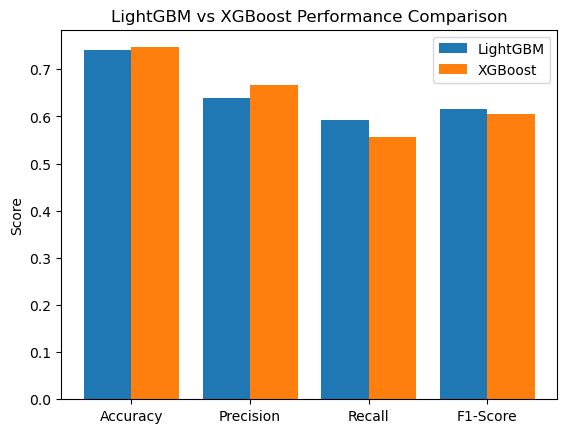

In [105]:
# 2.	Visualize and interpret the results to identify the strengths and weaknesses of each algorithm.
# Bar Chart Visualization
# -----------------------------
metrics = comparison_df.columns
x = np.arange(len(metrics))

plt.figure()
plt.bar(x - 0.2, comparison_df.loc["LightGBM"], width=0.4, label="LightGBM")
plt.bar(x + 0.2, comparison_df.loc["XGBoost"], width=0.4, label="XGBoost")
plt.xticks(x, metrics)
plt.ylabel("Score")
plt.title("LightGBM vs XGBoost Performance Comparison")
plt.legend()
plt.show()

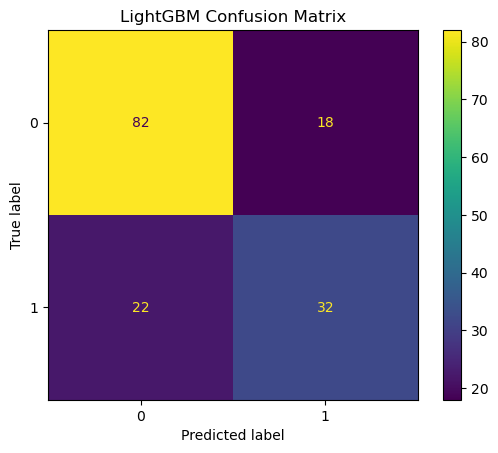

In [108]:
# Confusion Matrix LightGBM
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm_lgb = confusion_matrix(y_test, y_pred_lgb)
disp_lgb = ConfusionMatrixDisplay(cm_lgb)
disp_lgb.plot()
plt.title("LightGBM Confusion Matrix")
plt.show()

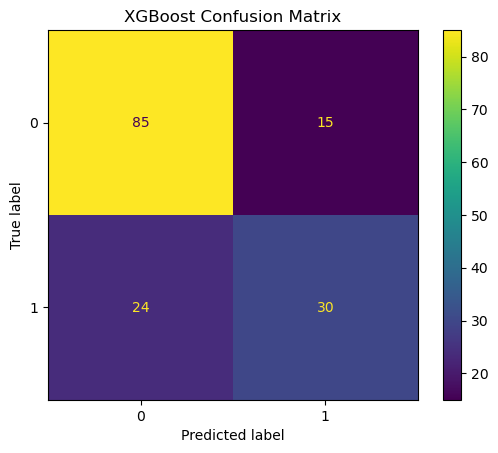

In [109]:
# Confusion Matrix XGBoost
cm_xgb = confusion_matrix(y_test, y_pred_xgboost)
disp_xgb = ConfusionMatrixDisplay(cm_xgb)
disp_xgb.plot()
plt.title("XGBoost Confusion Matrix")
plt.show()

The bar chart visualizes the comparison between LightGBM and XGBoost across Accuracy, Precision, Recall, and F1-score. Higher values indicate better performance. The confusion matrices show the distribution of correct and incorrect predictions. A higher diagonal value represents correct classifications, while off-diagonal values indicate misclassifications. These visualizations help identify that one model may better capture diabetic cases (recall) while the other may reduce false alarms (precision).

# A brief report summarizing the comparative analysis results and practical implications.

The comparative analysis shows that both LightGBM and XGBoost are powerful classifiers for diabetes prediction. XGBoost slightly outperforms LightGBM in terms of overall predictive quality, while LightGBM provides faster and efficient learning. Selecting the best model depends on whether the task emphasizes accuracy and recall or computational efficiency and scalability.